# CMB Parameter Estimation

This example demonstrates Bayesian inference of cosmological parameters from Cosmic Microwave Background (CMB) temperature power spectrum data using nested sampling.

## Background

The CMB is the relic radiation from the early universe, emitted approximately 380,000 years after the Big Bang when the universe cooled enough for electrons and protons to combine into neutral hydrogen. The CMB carries an imprint of the primordial density fluctuations that seeded the formation of galaxies and large-scale structure.

The angular power spectrum of CMB temperature fluctuations, $C_\ell$, encodes information about fundamental cosmological parameters:

- **$\Omega_b h^2$**: Physical baryon density
- **$\Omega_c h^2$**: Physical cold dark matter density  
- **$h$**: Dimensionless Hubble parameter ($H_0 = 100h$ km/s/Mpc)
- **$\tau$**: Optical depth to reionization
- **$n_s$**: Scalar spectral index of primordial perturbations
- **$\ln(10^{10}A_s)$**: Log amplitude of primordial perturbations

Computing the theoretical CMB power spectrum from these parameters requires solving the Boltzmann equations, which is computationally expensive. We use [CosmoPowerJAX](https://github.com/dpiras/cosmopower-jax), a neural network emulator that provides fast, differentiable predictions of $C_\ell$.

## Prerequisites

```bash
pip install git+https://github.com/handley-lab/blackjax.git@v0.1.0-beta
pip install cosmopower_jax anesthetic tqdm
```

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import blackjax
from blackjax.ns.utils import finalise
import tqdm
from anesthetic import NestedSamples
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
rng_key = jax.random.PRNGKey(0)

## CMB Likelihood

The observed CMB power spectrum at each multipole $\ell$ follows a $\chi^2$ distribution with $2\ell + 1$ degrees of freedom (from the $2\ell + 1$ independent $m$-modes). The likelihood for the observed spectrum $\hat{C}_\ell$ given the theoretical spectrum $C_\ell$ is:

$$
\mathcal{L}(\hat{C}_\ell | C_\ell) = \prod_\ell \frac{(2\ell+1)}{C_\ell} \chi^2_{2\ell+1}\left(\frac{(2\ell+1)\hat{C}_\ell}{C_\ell}\right)
$$

We implement this as a class that can both generate mock data and evaluate the log-likelihood:

In [ ]:
class CMB:
    """CMB power spectrum likelihood.
    
    Models the cosmic variance limited likelihood for CMB temperature
    power spectrum measurements.
    """
    def __init__(self, Cl):
        self.Cl = Cl
        self.ell = jnp.arange(2, 2509)

    def rvs(self, key, shape=()):
        """Generate random realizations of the power spectrum."""
        shape = tuple(jnp.atleast_1d(shape))
        return (
            jax.random.chisquare(key, 2 * self.ell + 1, shape + self.Cl.shape)
            * self.Cl
            / (2 * self.ell + 1)
        )

    def logpdf(self, x):
        """Compute log-likelihood of observed spectrum x."""
        return (
            jax.scipy.stats.chi2.logpdf(
                (2 * self.ell + 1) * x / self.Cl, 2 * self.ell + 1
            )
            + jnp.log(2 * self.ell + 1)
            - jnp.log(self.Cl)
        ).sum(axis=-1)

## Emulator and Mock Data

We load the CosmoPower emulator trained on CMB temperature power spectra and generate mock observed data using Planck-like cosmological parameters:

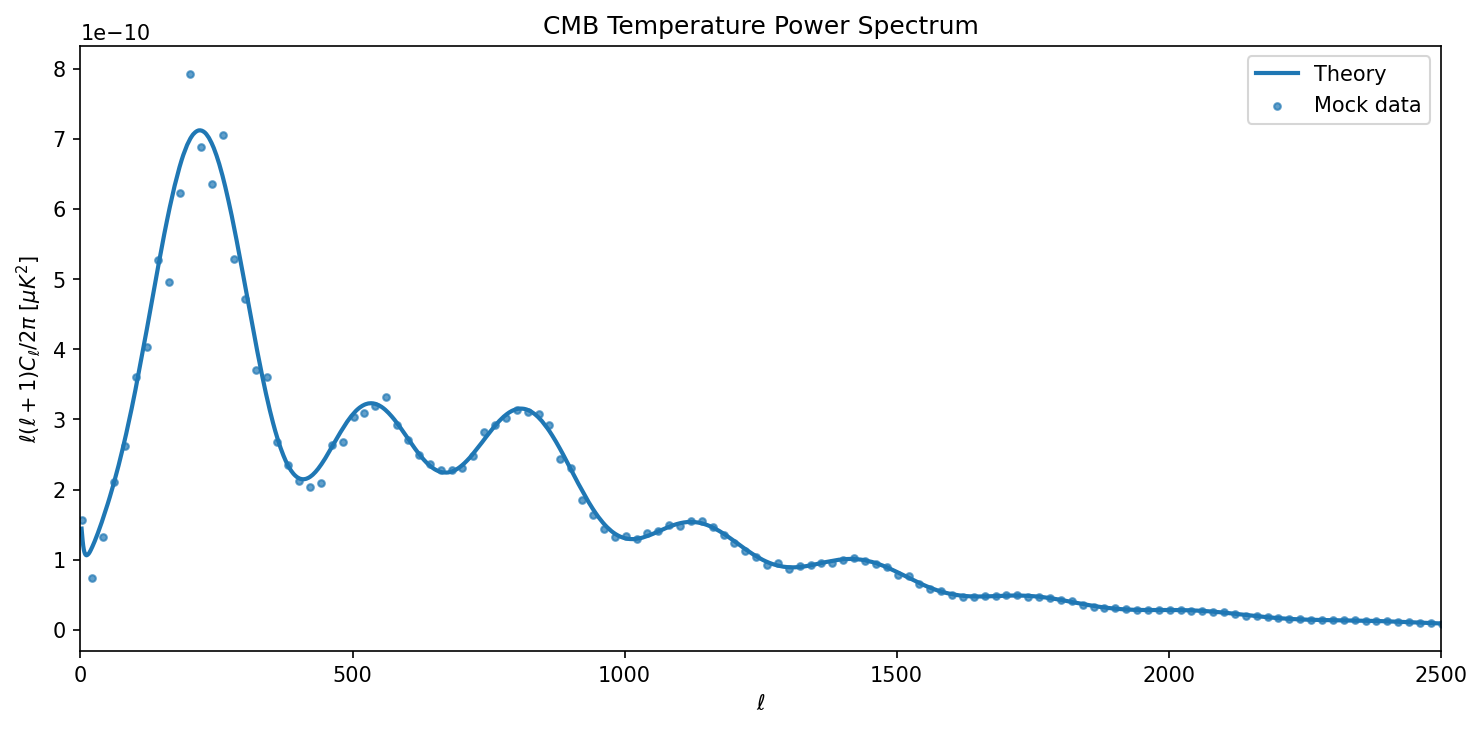

In [ ]:
# Load the CMB TT emulator
emulator = CosmoPowerJAX(probe="cmb_tt")

# Planck 2018 best-fit parameters: [Ωbh², Ωch², h, τ, ns, ln(10¹⁰As)]
planck_params = jnp.array([0.02225, 0.1198, 0.693, 0.097, 0.965, 3.05])

# Generate mock observed data
rng_key, data_key = jax.random.split(rng_key)
theory_Cl = emulator.predict(planck_params)
data = CMB(theory_Cl)
observed_Cl = data.rvs(data_key)

# Plot the power spectrum
ell = jnp.arange(2, 2509)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ell, ell * (ell + 1) * theory_Cl / (2 * jnp.pi), label="Theory", lw=2)
ax.scatter(ell[::20], (ell * (ell + 1) * observed_Cl / (2 * jnp.pi))[::20], 
           s=10, alpha=0.7, label="Mock data")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$ [$\mu K^2$]")
ax.set_title("CMB Temperature Power Spectrum")
ax.legend()
ax.set_xlim(0, 2500)
plt.tight_layout()

## Prior and Likelihood

We use uniform priors bounded by the emulator's training range:

In [ ]:
# Parameter names and labels for plotting
columns = ["Ωbh2", "Ωch2", "h", "τ", "ns", "lnA"]
labels = [
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$h$",
    r"$\tau$",
    r"$n_s$",
    r"$\ln(10^{10}A_s)$",
]

# Prior bounds (set by emulator training range)
param_min = jnp.array([0.01865, 0.05, 0.64, 0.04, 0.84, 1.61])
param_max = jnp.array([0.02625, 0.255, 0.82, 0.12, 1.1, 3.91])


def logprior_fn(x):
    """Uniform prior over cosmological parameters."""
    return jax.scipy.stats.uniform.logpdf(
        x, param_min, param_max - param_min
    ).sum()


@jax.jit
def loglikelihood_fn(x):
    """CMB likelihood given parameters."""
    return CMB(jnp.array(emulator.predict(x))).logpdf(observed_Cl)


# Test the likelihood at true parameters
print(f"Log-likelihood at true params: {loglikelihood_fn(planck_params):.1f}")

Log-likelihood at true params: 92610.2


## Run Nested Sampling

We configure the nested sampler with 1000 live points and run until convergence:

In [ ]:
n_dims = len(columns)
n_live = 1000
n_delete = 500
num_inner_steps = n_dims * 3

# Initialize sampler
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=n_delete,
    num_inner_steps=num_inner_steps,
)

# Sample initial particles from prior
rng_key, init_key = jax.random.split(rng_key)
initial_particles = (
    jax.random.uniform(init_key, (n_live, n_dims)) * (param_max - param_min)
    + param_min
)

# Initialize state
live = nested_sampler.init(initial_particles)
step = jax.jit(nested_sampler.step)

# Run sampling
dead_points = []
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        rng_key, subkey = jax.random.split(rng_key)
        live, dead = step(subkey, live)
        dead_points.append(dead)
        pbar.update(n_delete)

print(f"\nFinal log-evidence: {live.logZ:.1f}")

Dead points: 20500 dead points [04:26, 76.92 dead points/s]



Final log-evidence: 92587.4


## Results

We use anesthetic to process the nested samples and visualize the posterior:

In [ ]:
# Finalize the run
ns_run = finalise(live, dead_points)

# Create anesthetic NestedSamples object
samples = NestedSamples(
    data=ns_run.particles,
    logL=ns_run.loglikelihood,
    logL_birth=ns_run.loglikelihood_birth,
    columns=columns,
    labels=labels,
)

print(f"Log-evidence: {samples.logZ():.1f} ± {samples.logZ(100).std():.1f}")
print(f"Effective sample size: {samples.neff():.0f}")

Log-evidence: 92587.4 ± 0.2
Effective sample size: 5173


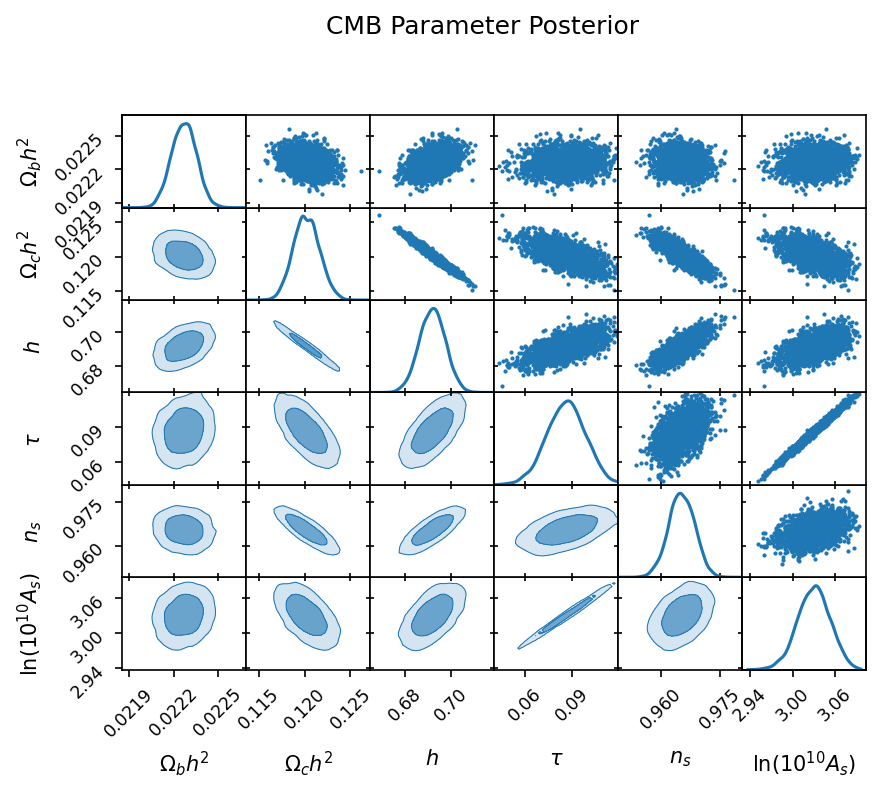

In [ ]:
# Corner plot showing posterior distributions
axes = samples.plot_2d(columns)
plt.suptitle("CMB Parameter Posterior", y=1.02)

In [ ]:
# Parameter summary
print("Parameter estimates (mean ± std):")
print("-" * 40)
for i, (col, label) in enumerate(zip(columns, labels)):
    mean = samples[col].mean()
    std = samples[col].std()
    true = planck_params[i]
    print(f"{label:20s}: {mean:.4f} ± {std:.4f}  (true: {true:.4f})")

Parameter estimates (mean ± std):
----------------------------------------
Ωbh2                : 0.0223 ± 0.0001  (true: 0.0222)
Ωch2                : 0.1202 ± 0.0014  (true: 0.1198)
h                   : 0.6919 ± 0.0057  (true: 0.6930)
τ                   : 0.0863 ± 0.0124  (true: 0.0970)
ns                  : 0.9653 ± 0.0033  (true: 0.9650)
lnA                 : 3.0299 ± 0.0226  (true: 0.0500)
